In [40]:
import numpy as np
import math as math
from scipy import optimize
import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

([<matplotlib.axis.YTick at 0x215d5f37110>,
 [Text(0, -50.0, '−50'),
  Text(0, -60.0, '−60'),
  Text(0, -70.0, '−70'),
  Text(0, -80.0, '−80'),
  Text(0, -90.0, '−90'),
  Text(0, -100.0, '−100')])

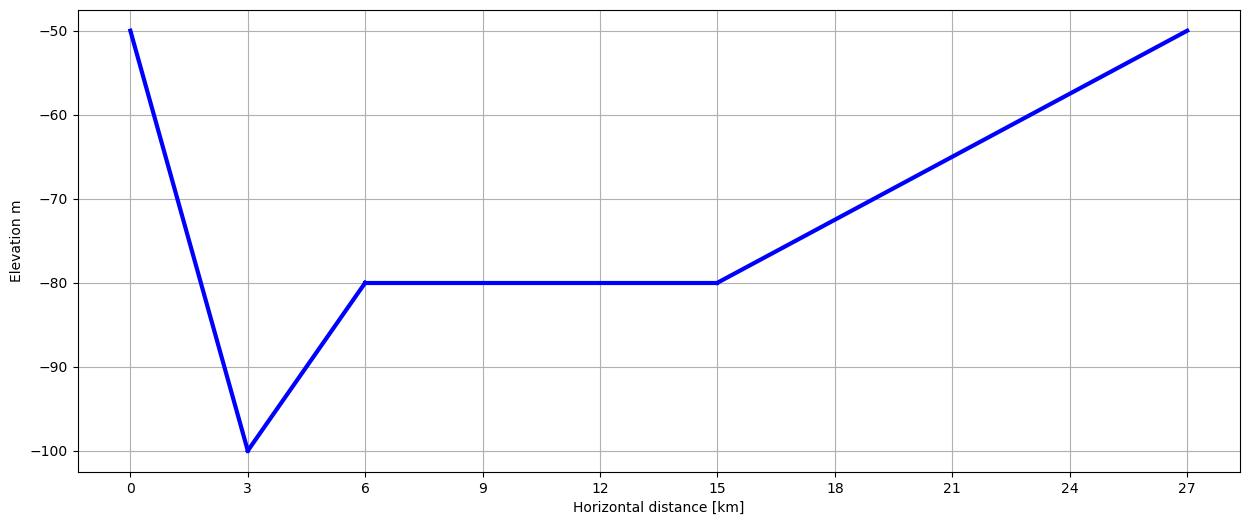

In [84]:
x1 = np.linspace(0, 3, 10)
x2 = np.linspace(3, 6, 10)
x3 = np.linspace(6, 15, 10)
x4 = np.linspace(15, 27, 10)

y1 = -50 - 50/3 * x1
y2 = -100 - (3-x2) * 20/3
y3 = -80 - (6-x3) * 0.000000001
y4 = -80 - (15-x4) * 30/12

xticks = np.linspace(0, 27, 10)
yticks = np.linspace(-50, -100, 6)

plt.figure()
plt.plot(x1, y1, 'b-', lw=3)
plt.plot(x2, y2, 'b-', lw=3)
plt.plot(x3, y3, 'b-', lw=3)
plt.plot(x4, y4, 'b-', lw=3)
plt.grid()
plt.xlabel('Horizontal distance [km]')
plt.ylabel('Elevation m')
plt.xticks(xticks)
plt.yticks(yticks)
# plt.title('Simplified elevation profile')

In [41]:
def catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L_susp):
    
    W = W_pm*L_susp*g
        
    s = L_susp    
    z_t1 = 1 + (V_AN/H_AN)**2
    z_t2 = 1 + ((V_AN - W*s/L_susp)/H_AN)**2
    z = W*s/EA * (s/2/L_susp - V_AN/W) - H_AN*L_susp/W*(np.sqrt(z_t1) - np.sqrt(z_t2))            
    x_susp = H_AN*s/EA + H_AN*L_susp/W*(np.arcsinh(V_AN/H_AN) - np.arcsinh((V_AN - W*s/L_susp)/H_AN))
    x_bed = L_tot - L_susp
    x = x_bed + x_susp
        
    return x, z

In [42]:
def catenary_xz(W_pm, L_tot, EA, V_AN, H_AN, L_susp, ds):
        
    W = W_pm * L_susp * g
    
    # c_s = [0]
    # c_x = [L_tot - L_susp]
    # c_z = [0]
    # c_H = [H_AN]
    # c_V = [V_AN]
    
    c_s = [0, 0]    
    c_x = [0, L_tot - L_susp]
    c_z = [0, 0]
    c_H = [H_AN, H_AN]
    c_V = [V_AN, V_AN]
    
    Ns = math.floor(L_susp/ds)
    ds = L_susp/Ns
    for i in range(1,Ns+1):
        s = c_s[-1]+ds        
        z_t1 = 1 + (V_AN/H_AN)**2
        z_t2 = 1 + ((V_AN - W*s/L_susp)/H_AN)**2
        z = W*s/EA * (s/2/L_susp-V_AN/W) - H_AN*L_susp/W*(np.sqrt(z_t1) - np.sqrt(z_t2))        
        x_susp = H_AN*s/EA + H_AN*L_susp/W*(np.arcsinh(V_AN/H_AN) - np.arcsinh((V_AN - W*s/L_susp)/H_AN))        
        V = V_AN + W_pm*s*g
        x = L_tot - L_susp + x_susp
        
        c_s.append(s)        
        c_x.append( x )
        c_z.append( z )        
        c_V.append( V )
        
    # print(c_s[-1], c_x[-1], c_z[-1], c_V[-1])
        
    return c_s, c_x, c_z, c_V

In [43]:
def objective_fnc(sol, *data):        
    H_AN = sol[0]
    L = sol[1] #suspended length
    W_pm, L_tot, EA, V_AN, xtarg, ztarg  = data
    x, z = catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L)    
    return np.array( [abs(ztarg-z),  abs(xtarg-x)] )

d0 =  72.5
anch_sep =  580.0
L1 = L2 =  300
x target side tunnel 276.0
z target mid tunnel 72.5
Length on bed: 147.05439006295452 ratio bed/tot 0.4901813002098484
Net Horizontal Force =  0.0
x1_moor, x2_moor =  276.0 276.0


C:\Users\bramv\AppData\Local\Temp\ipykernel_11228\1576483895.py:59: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol2_array = [optimize.fsolve(objective_fnc,


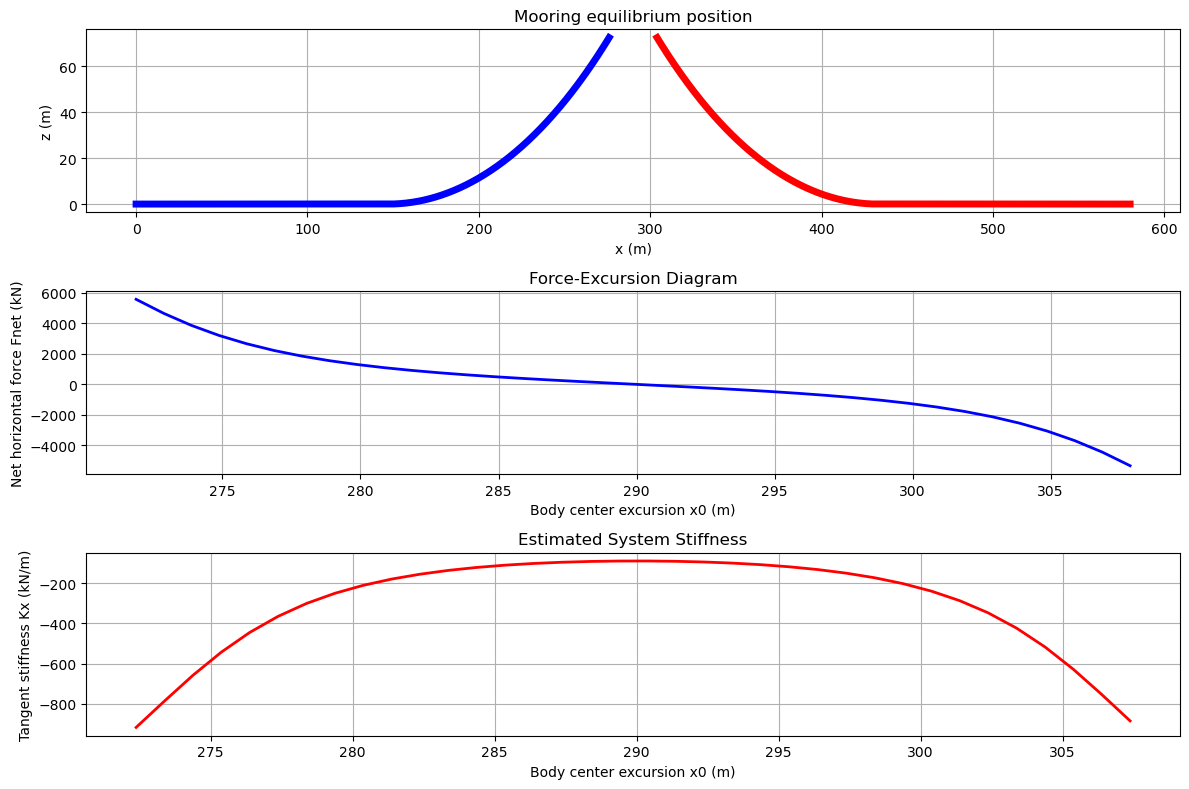

Range of Fnet (kN): -5326.7051716276565 to 5568.207538412255
Range of Kx (kN/m): -917.9165472273892 to -89.24082642386585
Stiffness at 0 excursion (kN/m): 89.24082642386585
d0 =  52.5
anch_sep =  420.0
L1 = L2 =  215
x target side tunnel 196.0
z target mid tunnel 52.5
Length on bed: 112.64959932368095 ratio bed/tot 0.5239516247613067
Net Horizontal Force =  0.0
x1_moor, x2_moor =  196.0 196.0


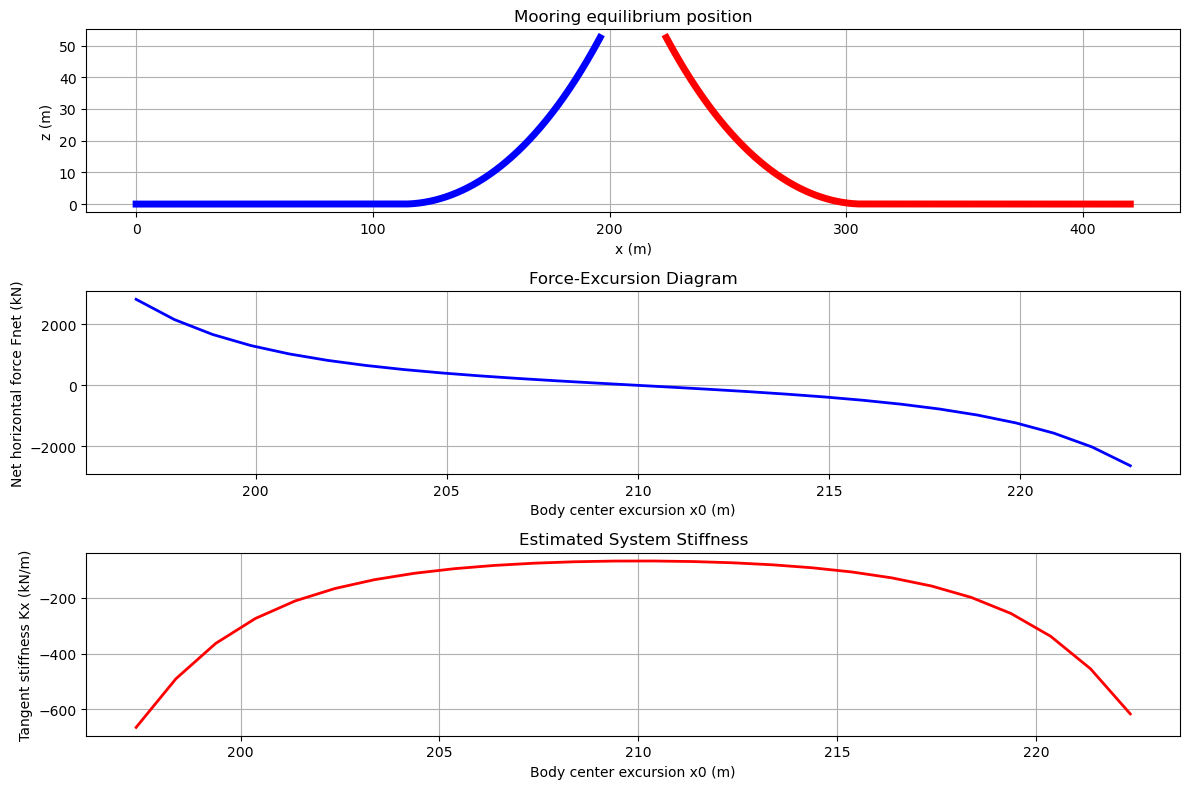

Range of Fnet (kN): -2641.74226834048 to 2826.9883983053855
Range of Kx (kN/m): -664.5224858503449 to -68.68129704202205
Stiffness at 0 excursion (kN/m): 68.68129704202205
d0 =  37.5
anch_sep =  300.0
L1 = L2 =  150
x target side tunnel 136.0
z target mid tunnel 37.5
Length on bed: 78.84534720095841 ratio bed/tot 0.5256356480063894
Net Horizontal Force =  0.0
x1_moor, x2_moor =  136.0 136.0


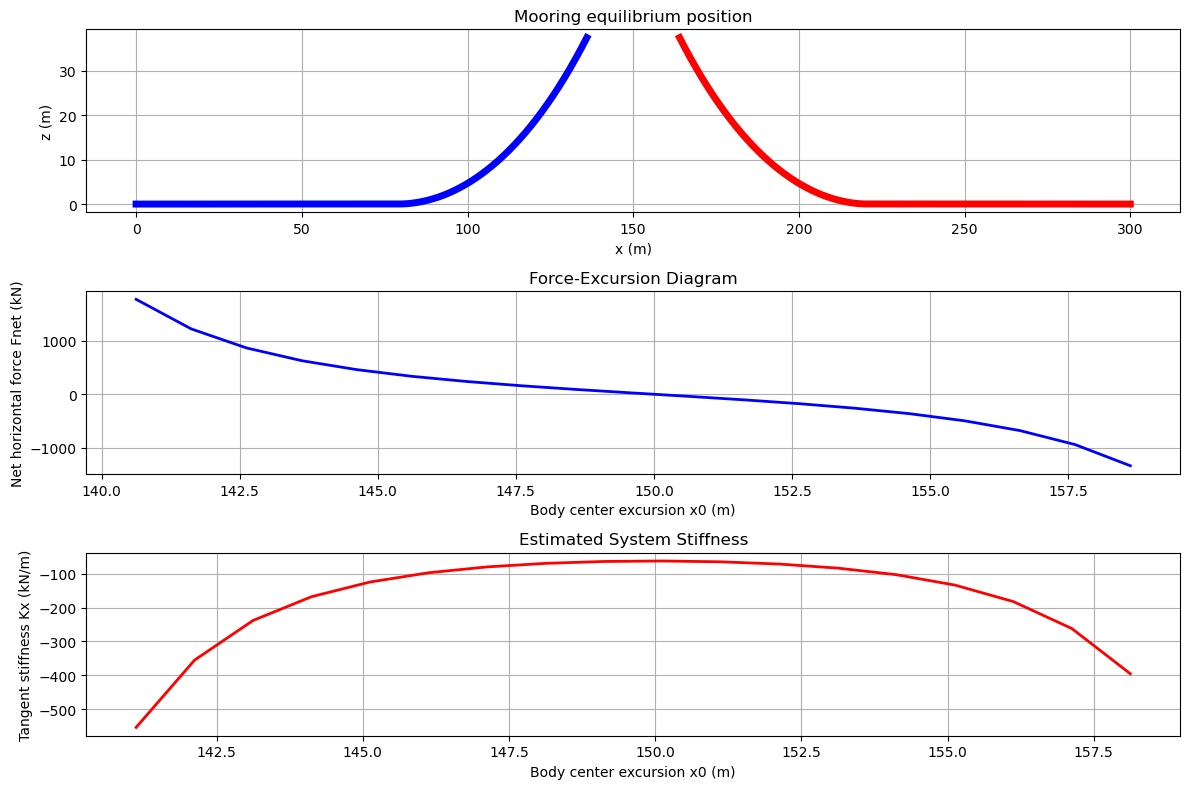

Range of Fnet (kN): -1336.51019469482 to 1774.8869340044446
Range of Kx (kN/m): -554.0503789628956 to -62.62193008348622
Stiffness at 0 excursion (kN/m): 62.62193008348622
d0 =  22.5
anch_sep =  180.0
L1 = L2 =  85
x target side tunnel 76.0
z target mid tunnel 22.5
Length on bed: 44.7837926616275 ratio bed/tot 0.5268681489603235
Net Horizontal Force =  0.0
x1_moor, x2_moor =  76.0 76.0


C:\Users\bramv\AppData\Local\Temp\ipykernel_11228\1576483895.py:55: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol1_array = [optimize.fsolve(objective_fnc,


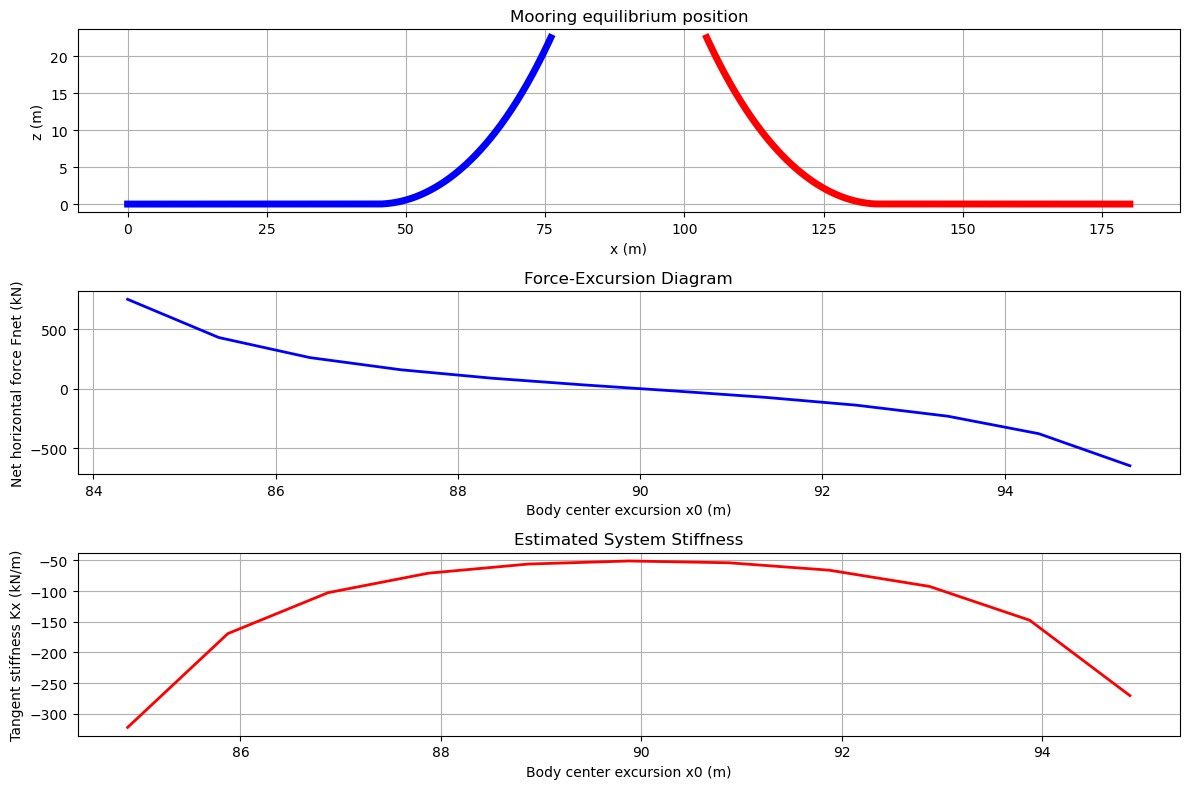

Range of Fnet (kN): -649.4586773710995 to 753.0038632155367
Range of Kx (kN/m): -321.8709537054249 to -51.151957152841526
Stiffness at 0 excursion (kN/m): 51.151957152841526


In [86]:
g = 9.81 #m/s2

W1_pm = 376 #kg/m
EA1 = 1850000000 #N

W2_pm = 376 #kg/m
EA2 = 1850000000 #N

moor_sep = 28 #m was 30

d0_arr = np.array([72.5, 52.5, 37.5, 22.5]) # height differences between tunnel midpoint and seabed
L_arr = np.array([300, 215, 150, 85]) # cable lengths, hardcoded to give nice catenary shapes

for i in range(len(d0_arr)):
    d0 = d0_arr[i]
    anch_sep = 8 * d0
    # L1_tot = L2_tot =  np.sqrt(d0**2 + (1/2 * anch_sep)**2)
    L1_tot = L2_tot = L_arr[i]
    print('d0 = ', d0 )
    print('anch_sep = ', anch_sep)
    print('L1 = L2 = ', L1_tot)

    x1_anch = 0
    x2_anch = anch_sep-x1_anch
    
#     Plotting original equilibrium position
    x0_targ, z0_targ = (anch_sep/2, d0)

    x1_targ, z1_targ = (x0_targ - moor_sep/2.0, d0)
    print('x target side tunnel', x1_targ)
    print('z target mid tunnel', z1_targ)
    data1 = (W1_pm, L1_tot, EA1, 0, x1_targ, z1_targ)
    # print('weight/m, length, EA =', data1)
    H1, L1_susp = optimize.fsolve(objective_fnc,np.array([10,10]),args=data1)
    L1_bed = L1_tot - L1_susp
    print('Length on bed:', L1_bed, 'ratio bed/tot', L1_bed/L1_tot)

    x2_targ, z2_targ = (anch_sep - moor_sep - x1_targ, d0)
    data2 = (W2_pm, L2_tot, EA2, 0, x2_targ, z2_targ)
    H2, L2_susp = optimize.fsolve(objective_fnc,np.array([10,10]),args=data2)

    print("Net Horizontal Force = ",(H2-H1)/1000)
    print("x1_moor, x2_moor = ",x1_targ, anch_sep-x2_targ-moor_sep)

    l1_s, l1_x, l1_z, l1_V = catenary_xz(W1_pm, L1_tot, EA1, 0, H1, L1_susp, 0.1)
    l2_s, l2_x, l2_z, l2_V = catenary_xz(W2_pm, L2_tot, EA2, 0, H2, L2_susp, 0.1)

# Force-excursion diagram
    x0_min = anch_sep / 2 - d0/4
    x0_max = anch_sep / 2 + d0/4
    x0_targ_array = np.arange(x0_min, x0_max)
    x1_targ_array = [x - moor_sep/2 for x in x0_targ_array]
    x2_targ_array = [anch_sep - moor_sep - x for x in x1_targ_array]

    sol1_array = [optimize.fsolve(objective_fnc,
                                np.array([10,10]),
                                args=(W1_pm, L1_tot, EA1, 0, lx, z1_targ)) 
                for lx in x1_targ_array]
    sol2_array = [optimize.fsolve(objective_fnc,
                                np.array([10,10]),
                                args=(W2_pm, L2_tot, EA2, 0, lx, z2_targ)) 
                for lx in x2_targ_array]

    H1_array = [sol[0] for sol in sol1_array]
    H2_array = [sol[0] for sol in sol2_array]

    # Net horizontal restoring force
    Fnet_array = np.array(H2_array) - np.array(H1_array)

    # Tangent stiffness from finite difference: Kx = dFnet/dx0
    dx = x0_targ_array[1] - x0_targ_array[0]
    Kx = np.diff(Fnet_array) / dx
    x0_mid = x0_targ_array[:-1] + dx / 2

    # Plots
    fig, ax = plt.subplots(3, 1, figsize=(12, 8))

    ax[0].plot(l1_x, l1_z, 'b-', lw=5)
    ax[0].plot([anch_sep-x for x in l2_x], l2_z, 'r-', lw=5)
    ax[0].grid(True)
    # ax[0].quiver(x0_targ, z0_targ, H2-H1, 0)
    ax[0].set_xlabel('x (m)')
    ax[0].set_ylabel('z (m)')
    ax[0].set_title('Mooring equilibrium position')
    
    ax[1].plot(x0_targ_array, Fnet_array / 1000, 'b-', lw=2)
    ax[1].grid(True)
    ax[1].set_xlabel('Body center excursion x0 (m)')
    ax[1].set_ylabel('Net horizontal force Fnet (kN)')
    ax[1].set_title('Force-Excursion Diagram')

    ax[2].plot(x0_mid, Kx / 1000, 'r-', lw=2)
    ax[2].grid(True)
    ax[2].set_xlabel('Body center excursion x0 (m)')
    ax[2].set_ylabel('Tangent stiffness Kx (kN/m)')
    ax[2].set_title('Estimated System Stiffness')

    plt.tight_layout()
    plt.show()

    print('Range of Fnet (kN):', np.min(Fnet_array)/1000, 'to', np.max(Fnet_array)/1000)
    print('Range of Kx (kN/m):', np.min(Kx)/1000, 'to', np.max(Kx)/1000)
    print('Stiffness at 0 excursion (kN/m):', np.abs(np.max(Kx)/1000))

In [60]:
print(d0_arr)

for i in range(len(d0_arr)):
    d0 = d0_arr[i]
    anch_sep = 8 * d0
    L1_tot = L2_tot = L_arr[i]

    print(L1_tot / d0)

    # print(d0)
    # print(anch_sep / 2)
    # print(d0 / (anch_sep / 2))

[72.5 52.5 37.5 22.5]
4.137931034482759
4.076190476190476
4.0
3.7777777777777777


([<matplotlib.axis.YTick at 0x215d5f41130>,
 [Text(0, -50.0, '−50'),
  Text(0, -60.0, '−60'),
  Text(0, -70.0, '−70'),
  Text(0, -80.0, '−80'),
  Text(0, -90.0, '−90'),
  Text(0, -100.0, '−100')])

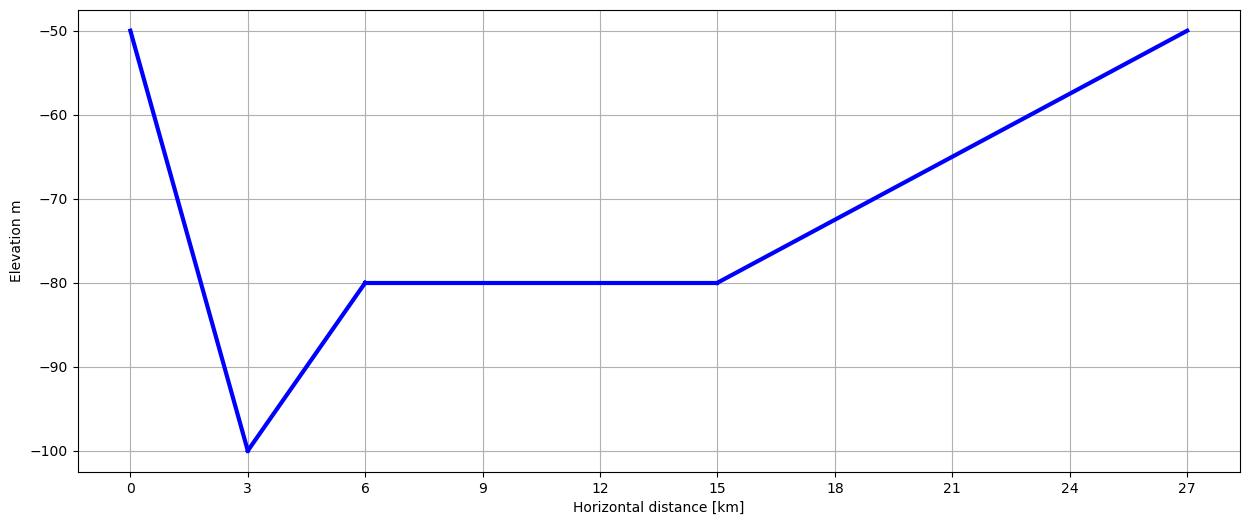